In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import torch
from inference import FloodInferenceEngine
from hyetograph import build_conditioning_vector
from config import Config

cfg = Config()

# ── Load Engine ───────────────────────────────────────────────────────────────
engine = FloodInferenceEngine(
    inference_config_path = 'checkpoints/inference_config.json',
    spatial_data_path     = 'checkpoints/spatial_data.npz',
)

# ── Predict with Confidence ───────────────────────────────────────────────────
@torch.no_grad()
def predict_with_confidence(engine, storm_type, depth_mm, hasDrainage, hasSoil,
                             tpeak=None, batch_size=512):
    conditioning_np, warnings = build_conditioning_vector(
        storm_type  = storm_type,
        depth_mm    = depth_mm,
        rain_min    = engine.rain_min,
        rain_max    = engine.rain_max,
        depth_min   = engine.depth_min,   
        depth_max   = engine.depth_max,   
        hasDrainage = hasDrainage,
        hasSoil     = hasSoil,
        tpeak       = tpeak,
    )
    conditioning_all = np.tile(conditioning_np[np.newaxis], (engine.patches_per_map, 1))
    spatial_all = np.stack([
        engine._apply_channel_masking(engine.spatial_patches[i], hasDrainage, hasSoil)
        for i in range(engine.patches_per_map)
    ])
    patch_preds = []
    patch_confs = []
    for start in range(0, engine.patches_per_map, batch_size):
        end           = min(start + batch_size, engine.patches_per_map)
        spatial_batch = torch.from_numpy(spatial_all[start:end]).float().to(engine.device)
        cond_batch    = torch.from_numpy(conditioning_all[start:end]).float().to(engine.device)
        logits, _     = engine.model(spatial_batch, cond_batch)
        probs         = torch.softmax(logits, dim=1)
        patch_preds.append(probs.argmax(dim=1).cpu().numpy())
        patch_confs.append(probs.max(dim=1).values.cpu().numpy())
    patch_preds = np.concatenate(patch_preds)
    patch_confs = np.concatenate(patch_confs)
    return {
        'flood_map'  : engine._reconstruct_map(patch_preds),
        'conf_map'   : engine._reconstruct_map(patch_confs.astype(np.float32)),
        'patch_preds': patch_preds,
        'patch_confs': patch_confs,
        'warnings'   : warnings,
        'config'     : {
            'storm_type' : storm_type,
            'depth_mm'   : depth_mm,
            'tpeak'      : tpeak,
            'hasDrainage': hasDrainage,
            'hasSoil'    : hasSoil,
        },
    }


  Best fold   : 2
  Model path  : checkpoints\fold_2\best_model.pt
✓ Spatial patches loaded: (6400, 11, 4, 4)
  Best macro F1 (saved): 0.5164
✓ Model loaded from: checkpoints\fold_2\best_model.pt
  Device : cpu
  Patches: 6,400 per prediction


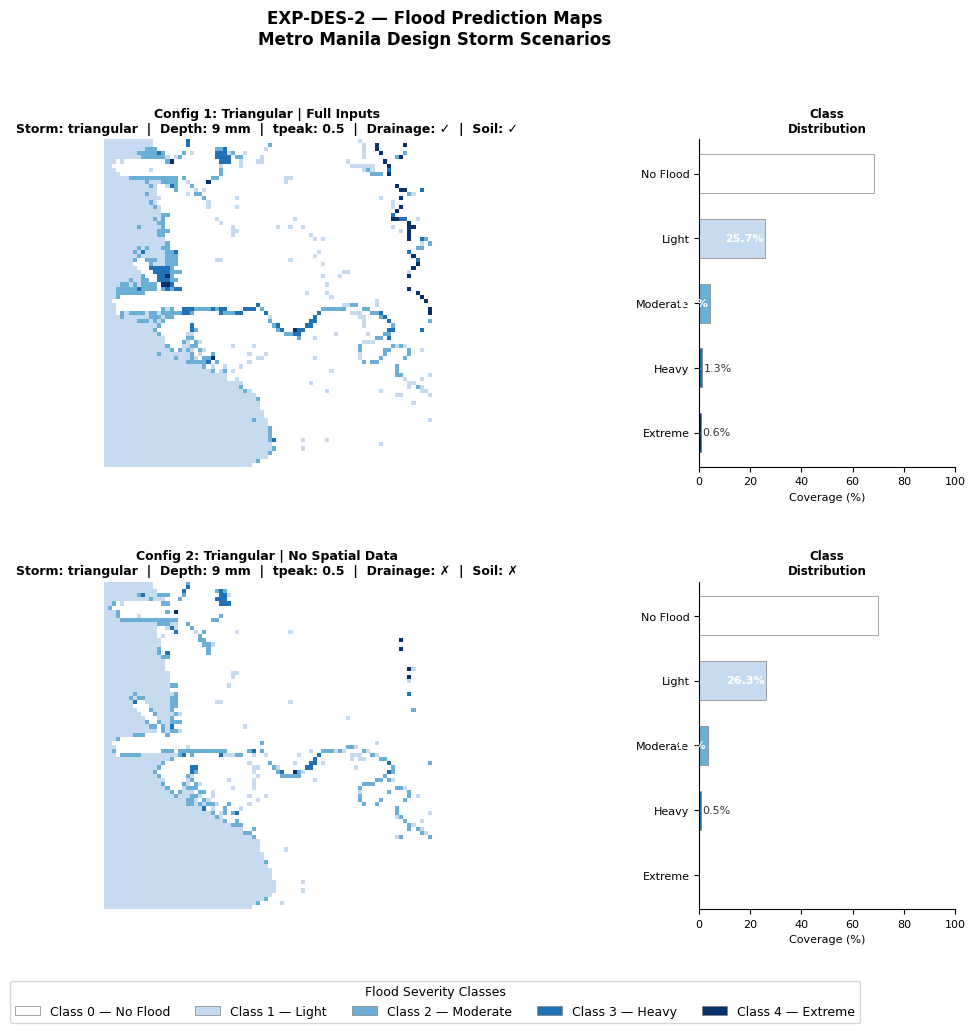

✓ Flood map figure saved → checkpoints\web_inference_flood_maps.png


In [ ]:
# ── Run Predictions ───────────────────────────────────────────────────────────
result1 = predict_with_confidence(
    engine, storm_type='triangular', depth_mm=9,
    tpeak=0.5, hasDrainage=True, hasSoil=True
)
result2 = predict_with_confidence(
    engine, storm_type='triangular', depth_mm=9,
    tpeak=0.5, hasDrainage=False, hasSoil=False
)

# ── Visualization Helpers ─────────────────────────────────────────────────────
FLOOD_COLORS = {
    0: '#FFFFFF',  # No susceptibility — white/clear
    1: '#C6DBEF',  # Low — light blue
    2: '#6BAED6',  # Moderate — medium blue
    3: '#2171B5',  # High — deep blue
    4: '#08306B',  # Very high — dark navy
}

FLOOD_LABELS = {0: 'No Flood', 1: 'Light', 2: 'Moderate', 3: 'Heavy', 4: 'Extreme'}

flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)
legend_patches = [
    mpatches.Patch(facecolor=FLOOD_COLORS[i], edgecolor='gray',
                   linewidth=0.5, label=f'Class {i} — {FLOOD_LABELS[i]}')
    for i in range(5)
]

def build_subtitle(cfg: dict) -> str:
    parts = [f"Storm: {cfg['storm_type']}", f"Depth: {cfg['depth_mm']} mm"]
    if cfg['tpeak'] is not None:
        parts.append(f"tpeak: {cfg['tpeak']}")
    parts.append(f"Drainage: {'✓' if cfg['hasDrainage'] else '✗'}")
    parts.append(f"Soil: {'✓' if cfg['hasSoil'] else '✗'}")
    return '  |  '.join(parts)

def compute_class_pcts(flood_map):
    total = flood_map.size
    return {i: 100 * (flood_map == i).sum() / total for i in range(5)}

def add_warning_banner(ax, warnings):
    if warnings:
        ax.text(
            0.5, 0.02,
            f'⚠ {len(warnings)} warning(s) — inputs outside training range',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=7.5, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#B8860B',
                      edgecolor='none', alpha=0.88),
        )

fig1, axes1 = plt.subplots(
    2, 2,
    figsize=(13, 10),
    gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.35, 'wspace': 0.25},
)

for row, (result, label) in enumerate([
    (result1, 'Config 1: Triangular | Full Inputs'),
    (result2, 'Config 2: Triangular | No Spatial Data'),
]):
    ax_flood = axes1[row, 0]
    ax_bar   = axes1[row, 1]
    pcts     = compute_class_pcts(result['flood_map'])

    # Flood map
    ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                    interpolation='nearest')
    ax_flood.set_title(f"{label}\n{build_subtitle(result['config'])}",
                       fontsize=9, fontweight='bold', pad=5)
    ax_flood.axis('off')
    add_warning_banner(ax_flood, result['warnings'])

    # Bar chart
    labels = [FLOOD_LABELS[i] for i in range(5)]
    values = [pcts[i] for i in range(5)]
    colors = [FLOOD_COLORS[i] for i in range(5)]
    bars   = ax_bar.barh(labels, values, color=colors,
                         edgecolor='gray', linewidth=0.5, height=0.6)
    for bar, val in zip(bars, values):
        if val > 1.5:
            ax_bar.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
                        f'{val:.1f}%', va='center', ha='right',
                        fontsize=8, color='white', fontweight='bold')
        elif val > 0.1:
            ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                        f'{val:.1f}%', va='center', ha='left',
                        fontsize=8, color='#333333')
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel('Coverage (%)', fontsize=8)
    ax_bar.set_title('Class\nDistribution', fontsize=8.5, fontweight='bold', pad=5)
    ax_bar.tick_params(axis='both', labelsize=8)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.invert_yaxis()

fig1.legend(
    handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
    frameon=True, title='Flood Severity Classes', title_fontsize=9,
    bbox_to_anchor=(0.5, -0.01),
)
fig1.suptitle(
    'EXP-DES-2 — Flood Prediction Maps\nMetro Manila Design Storm Scenarios',
    fontsize=12, fontweight='bold', y=1.01,
)
save1 = str(cfg.train.output_dir / 'web_inference_flood_maps.png')
plt.savefig(save1, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Flood map figure saved → {save1}")

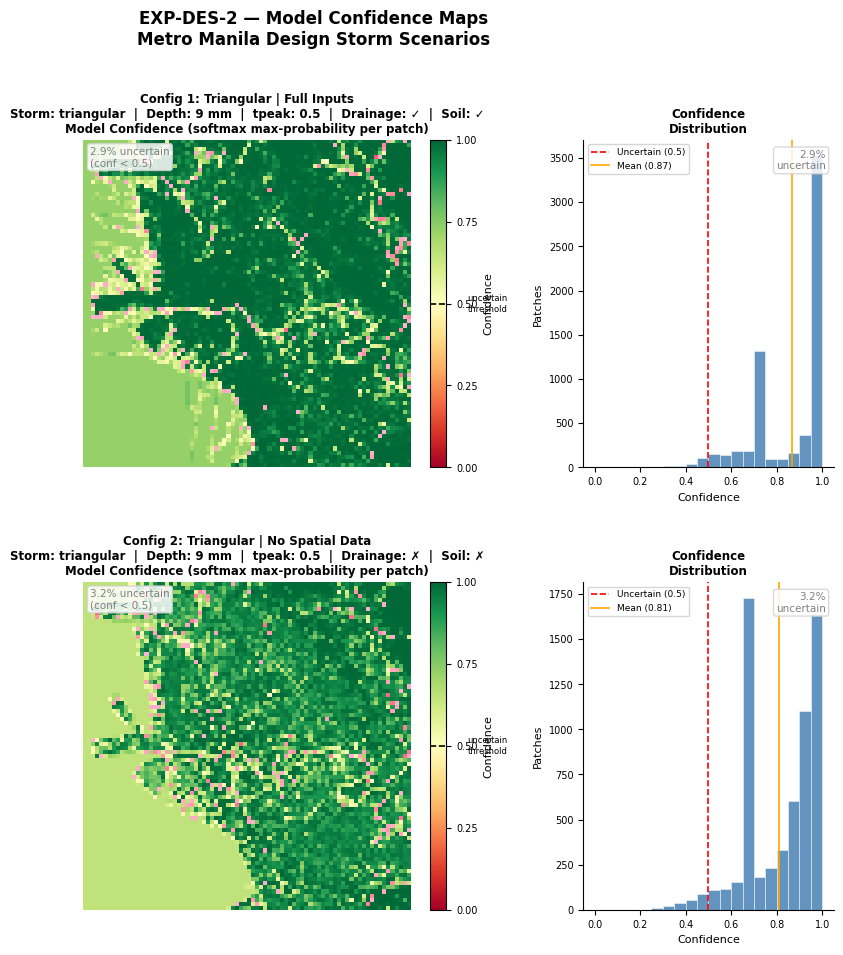

✓ Confidence map figure saved → checkpoints\web_inference_confidence_maps.png

Prediction & Confidence Summary
-------------------------------------------------------

  Config 1 — Full Inputs
    Mean confidence   : 0.8667
    Std  confidence   : 0.1591
    Min  confidence   : 0.2315
    Max  confidence   : 0.9976
    Uncertain patches : 185 / 6,400 (2.9%)
    No warnings — inputs within training distribution ✓

  Config 2 — No Spatial Data
    Mean confidence   : 0.8083
    Std  confidence   : 0.1581
    Min  confidence   : 0.2461
    Max  confidence   : 0.9973
    Uncertain patches : 205 / 6,400 (3.2%)
    No warnings — inputs within training distribution ✓


In [7]:
fig2, axes2 = plt.subplots(
    2, 2,
    figsize=(13, 10),
    gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.35, 'wspace': 0.30},
)

conf_cmap = 'RdYlGn'

for row, (result, label) in enumerate([
    (result1, 'Config 1: Triangular | Full Inputs'),
    (result2, 'Config 2: Triangular | No Spatial Data'),
]):
    ax_conf  = axes2[row, 0]
    ax_hist  = axes2[row, 1]
    conf_map    = result['conf_map']
    patch_confs = result['patch_confs']
    frac_low    = (patch_confs < 0.5).mean() * 100

    # ── Confidence map ────────────────────────────────────────────────────────
    im = ax_conf.imshow(conf_map, cmap=conf_cmap, vmin=0.0, vmax=1.0,
                        interpolation='nearest')
    ax_conf.set_title(
        f"{label}\n{build_subtitle(result['config'])}\nModel Confidence (softmax max-probability per patch)",
        fontsize=8.5, fontweight='bold', pad=5,
    )
    ax_conf.axis('off')
    add_warning_banner(ax_conf, result['warnings'])

    # Colorbar
    cbar = plt.colorbar(im, ax=ax_conf, fraction=0.035, pad=0.03)
    cbar.set_label('Confidence', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
    cbar.ax.axhline(y=0.5, color='black', linewidth=1.2, linestyle='--')
    cbar.ax.text(2.3, 0.5, 'uncertain\nthreshold', fontsize=6,
                 va='center', color='black')

    # Uncertain patch overlay
    uncertain_overlay = conf_map.copy().astype(float)
    uncertain_overlay[conf_map >= 0.5] = np.nan
    uncertain_overlay[conf_map <  0.5] = 1.0
    ax_conf.imshow(uncertain_overlay, cmap='cool', alpha=0.30,
                   vmin=0, vmax=1, interpolation='nearest')

    # % uncertain annotation
    ax_conf.text(
        0.02, 0.98,
        f'{frac_low:.1f}% uncertain\n(conf < 0.5)',
        transform=ax_conf.transAxes, ha='left', va='top', fontsize=7.5,
        color='red' if frac_low > 20 else 'gray',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='lightgray', alpha=0.85),
    )

    # ── Histogram ─────────────────────────────────────────────────────────────
    ax_hist.hist(patch_confs, bins=20, range=(0, 1),
                 color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax_hist.axvline(x=0.5, color='red', linewidth=1.2, linestyle='--',
                    label='Uncertain (0.5)')
    ax_hist.axvline(x=patch_confs.mean(), color='orange', linewidth=1.2,
                    linestyle='-', label=f"Mean ({patch_confs.mean():.2f})")
    ax_hist.set_xlabel('Confidence', fontsize=8)
    ax_hist.set_ylabel('Patches', fontsize=8)
    ax_hist.set_title('Confidence\nDistribution', fontsize=8.5,
                      fontweight='bold', pad=5)
    ax_hist.tick_params(labelsize=7)
    ax_hist.legend(fontsize=6.5, loc='upper left')
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.text(
        0.97, 0.97,
        f'{frac_low:.1f}%\nuncertain',
        transform=ax_hist.transAxes, ha='right', va='top', fontsize=7.5,
        color='red' if frac_low > 20 else 'gray',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='lightgray', alpha=0.85),
    )

fig2.suptitle(
    'EXP-DES-2 — Model Confidence Maps\nMetro Manila Design Storm Scenarios',
    fontsize=12, fontweight='bold', y=1.01,
)
save2 = str(cfg.train.output_dir / 'web_inference_confidence_maps.png')
plt.savefig(save2, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Confidence map figure saved → {save2}")

# ── Console Summary ───────────────────────────────────────────────────────────
print("\nPrediction & Confidence Summary")
print("-" * 55)
for label, result in [('Config 1 — Full Inputs', result1),
                       ('Config 2 — No Spatial Data', result2)]:
    confs = result['patch_confs']
    print(f"\n  {label}")
    print(f"    Mean confidence   : {confs.mean():.4f}")
    print(f"    Std  confidence   : {confs.std():.4f}")
    print(f"    Min  confidence   : {confs.min():.4f}")
    print(f"    Max  confidence   : {confs.max():.4f}")
    print(f"    Uncertain patches : {(confs < 0.5).sum():,} / {len(confs):,} "
          f"({100*(confs < 0.5).mean():.1f}%)")
    if result['warnings']:
        for w in result['warnings']:
            print(f"    ⚠ {w}")
    else:
        print(f"    No warnings — inputs within training distribution ✓")

In [10]:
import rasterio
import numpy as np
from rasterio.transform import from_bounds
import rasterio.crs

def save_result_as_tif(result: dict, save_path: str, transform, crs, map_size: tuple = (320, 320)) -> None:
    flood_map = result['flood_map'].astype(np.float32)   # (320, 320)
    conf_map  = result['conf_map'].astype(np.float32)    # (320, 320)
    H, W      = map_size

    with rasterio.open(
        save_path,
        mode      = 'w',
        driver    = 'GTiff',
        height    = H,
        width     = W,
        count     = 2,
        dtype     = 'float32',
        crs       = crs,
        transform = transform,
        compress  = 'lzw',
    ) as dst:
        dst.write(flood_map, 1)   # Band 1 — flood class
        dst.write(conf_map,  2)   # Band 2 — confidence

        # Band descriptions — readable in QGIS / ArcGIS
        dst.update_tags(1, description='Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)')
        dst.update_tags(2, description='Model Confidence (softmax max-probability per patch 0.0-1.0)')

        # File-level metadata
        dst.update_tags(
            model       = 'EXP-DES-2 ViTFloodClassifier',
            storm_type  = result['config']['storm_type'],
            depth_mm    = str(result['config']['depth_mm']),
            tpeak       = str(result['config']['tpeak']),
            hasDrainage = str(result['config']['hasDrainage']),
            hasSoil     = str(result['config']['hasSoil']),
        )

    print(f"✓ GeoTIFF saved → {save_path}")
    print(f"  Band 1 : Flood class  (float32, 0–4)")
    print(f"  Band 2 : Confidence   (float32, 0.0–1.0)")
    print(f"  CRS    : {crs}")
    print(f"  Size   : {W}×{H} px")
    print(f"  Transform : {transform}")

dem_crs = rasterio.crs.CRS.from_epsg(3857)
dem_transform = rasterio.transform.Affine(30.0, 0.0, 13462980.0,
                                           0.0, -30.0, 1647690.0)

# ── Save both configs ─────────────────────────────────────────────────────────
save_result_as_tif(
    result    = result1,
    save_path = str(cfg.train.output_dir / 'web_inference_config1.tif'),
    transform = dem_transform,
    crs       = dem_crs,
)

save_result_as_tif(
    result    = result2,
    save_path = str(cfg.train.output_dir / 'web_inference_config2.tif'),
    transform = dem_transform,
    crs       = dem_crs,
)

✓ GeoTIFF saved → checkpoints\web_inference_config1.tif
  Band 1 : Flood class  (float32, 0–4)
  Band 2 : Confidence   (float32, 0.0–1.0)
  CRS    : EPSG:3857
  Size   : 320×320 px
  Transform : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.00|
✓ GeoTIFF saved → checkpoints\web_inference_config2.tif
  Band 1 : Flood class  (float32, 0–4)
  Band 2 : Confidence   (float32, 0.0–1.0)
  CRS    : EPSG:3857
  Size   : 320×320 px
  Transform : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.00|



GeoTIFF: checkpoints\web_inference_config1.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Storm     : triangular  9mm  tpeak=0.5  Drainage=True  Soil=True
✓ Visualization saved → checkpoints\web_inference_config1_viz.png


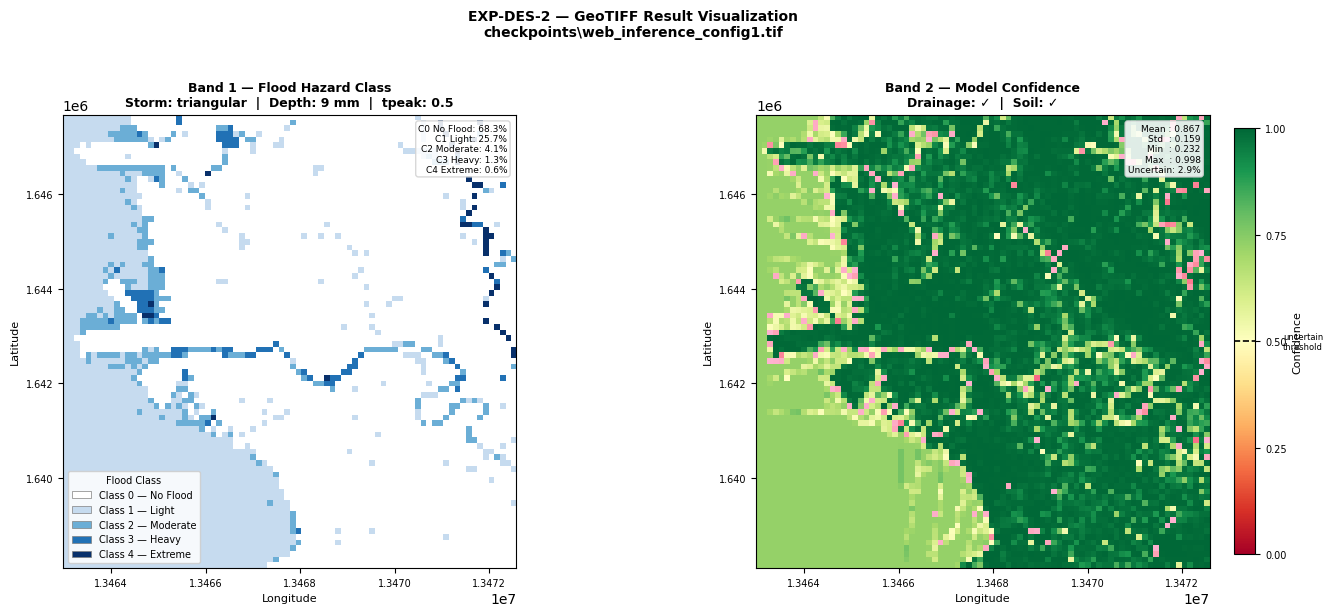


GeoTIFF: checkpoints\web_inference_config2.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Storm     : triangular  9mm  tpeak=0.5  Drainage=False  Soil=False
✓ Visualization saved → checkpoints\web_inference_config2_viz.png


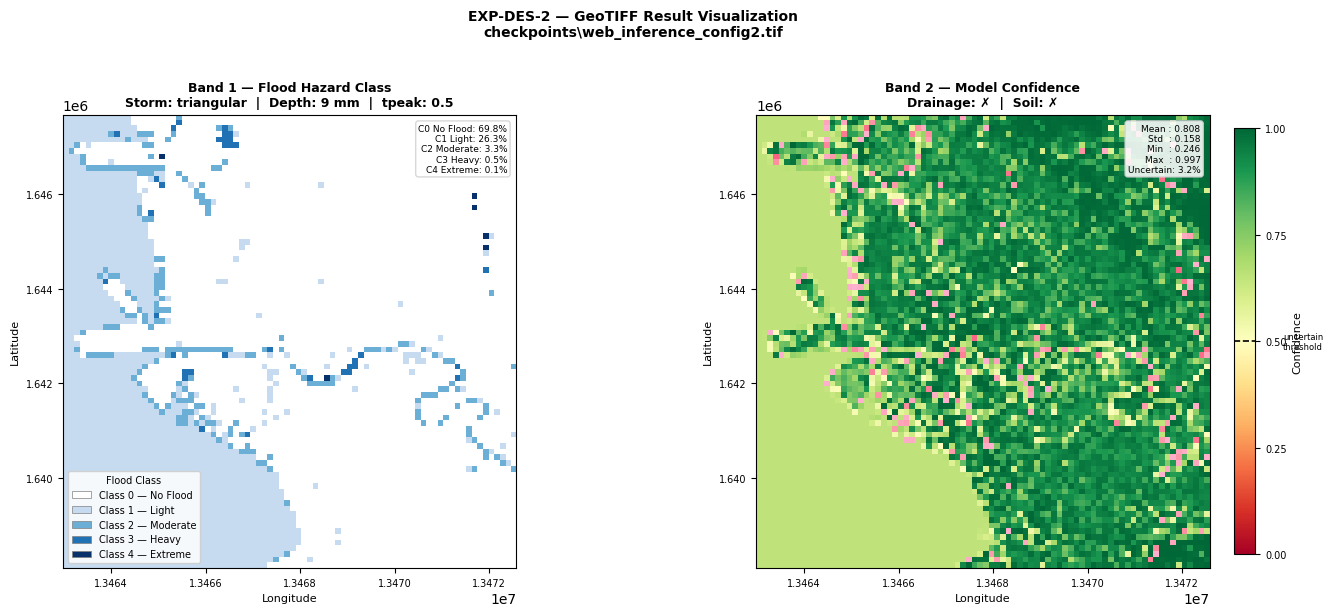

In [11]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from rasterio.plot import show

def visualize_result_tif(
    tif_path    : str,
    save_path   : str = None,
    figsize     : tuple = (14, 6),
) -> None:
    flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
    flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)
    conf_cmap  = 'RdYlGn'

    with rasterio.open(tif_path) as src:
        band1     = src.read(1)                  # flood class
        band2     = src.read(2)                  # confidence
        extent    = [
            src.bounds.left, src.bounds.right,
            src.bounds.bottom, src.bounds.top,
        ]
        crs       = src.crs
        tags      = src.tags()
        b1_tags   = src.tags(1)
        b2_tags   = src.tags(2)

    # ── Print metadata ────────────────────────────────────────────────────────
    print(f"\nGeoTIFF: {tif_path}")
    print(f"  CRS       : {crs}")
    print(f"  Extent    : {extent}")
    print(f"  Band 1    : {b1_tags.get('description', 'Flood class')}")
    print(f"  Band 2    : {b2_tags.get('description', 'Confidence')}")
    print(f"  Storm     : {tags.get('storm_type','?')}  "
          f"{tags.get('depth_mm','?')}mm  "
          f"tpeak={tags.get('tpeak','?')}  "
          f"Drainage={tags.get('hasDrainage','?')}  "
          f"Soil={tags.get('hasSoil','?')}")

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ── Band 1: Flood class ───────────────────────────────────────────────────
    ax1 = axes[0]
    im1 = ax1.imshow(
        band1, cmap=flood_cmap, norm=flood_norm,
        extent=extent, interpolation='nearest',
        origin='upper',
    )
    ax1.set_title(
        f"Band 1 — Flood Hazard Class\n"
        f"Storm: {tags.get('storm_type','?')}  |  "
        f"Depth: {tags.get('depth_mm','?')} mm  |  "
        f"tpeak: {tags.get('tpeak','?')}",
        fontsize=9, fontweight='bold', pad=6,
    )
    ax1.set_xlabel('Longitude', fontsize=8)
    ax1.set_ylabel('Latitude',  fontsize=8)
    ax1.tick_params(labelsize=7)

    # Flood class legend
    legend_patches = [
        mpatches.Patch(facecolor=FLOOD_COLORS[i], edgecolor='gray',
                       linewidth=0.5, label=f'Class {i} — {FLOOD_LABELS[i]}')
        for i in range(5)
    ]
    ax1.legend(handles=legend_patches, loc='lower left', fontsize=7,
               framealpha=0.85, title='Flood Class', title_fontsize=7)

    # Class distribution annotation
    total = band1.size
    dist  = '\n'.join([
        f"C{i} {FLOOD_LABELS[i]}: {100*(band1==i).sum()/total:.1f}%"
        for i in range(5)
    ])
    ax1.text(
        0.98, 0.98, dist,
        transform=ax1.transAxes, ha='right', va='top',
        fontsize=6.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='lightgray', alpha=0.88),
    )

    # ── Band 2: Confidence ────────────────────────────────────────────────────
    ax2  = axes[1]
    im2  = ax2.imshow(
        band2, cmap=conf_cmap, vmin=0.0, vmax=1.0,
        extent=extent, interpolation='nearest',
        origin='upper',
    )
    ax2.set_title(
        f"Band 2 — Model Confidence\n"
        f"Drainage: {'✓' if tags.get('hasDrainage')=='True' else '✗'}  |  "
        f"Soil: {'✓' if tags.get('hasSoil')=='True' else '✗'}",
        fontsize=9, fontweight='bold', pad=6,
    )
    ax2.set_xlabel('Longitude', fontsize=8)
    ax2.set_ylabel('Latitude',  fontsize=8)
    ax2.tick_params(labelsize=7)

    # Colorbar
    cbar = fig.colorbar(im2, ax=ax2, fraction=0.035, pad=0.04)
    cbar.set_label('Confidence', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
    cbar.ax.axhline(y=0.5, color='black', linewidth=1.2, linestyle='--')
    cbar.ax.text(2.3, 0.5, 'uncertain\nthreshold',
                 fontsize=6, va='center', color='black')

    # Uncertain patch overlay
    uncertain_overlay = band2.copy()
    uncertain_overlay[band2 >= 0.5] = np.nan
    uncertain_overlay[band2 <  0.5] = 1.0
    ax2.imshow(uncertain_overlay, cmap='cool', alpha=0.30,
               vmin=0, vmax=1, extent=extent,
               interpolation='nearest', origin='upper')

    # Confidence stats annotation
    frac_low = (band2 < 0.5).mean() * 100
    stats    = (
        f"Mean : {band2.mean():.3f}\n"
        f"Std  : {band2.std():.3f}\n"
        f"Min  : {band2.min():.3f}\n"
        f"Max  : {band2.max():.3f}\n"
        f"Uncertain: {frac_low:.1f}%"
    )
    ax2.text(
        0.98, 0.98, stats,
        transform=ax2.transAxes, ha='right', va='top',
        fontsize=6.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='lightgray', alpha=0.88),
    )

    fig.suptitle(
        f'EXP-DES-2 — GeoTIFF Result Visualization\n{tif_path}',
        fontsize=10, fontweight='bold', y=1.02,
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"✓ Visualization saved → {save_path}")

    plt.show()


# ── Visualize both saved TIFFs ────────────────────────────────────────────────
visualize_result_tif(
    tif_path  = str(cfg.train.output_dir / 'web_inference_config1.tif'),
    save_path = str(cfg.train.output_dir / 'web_inference_config1_viz.png'),
)

visualize_result_tif(
    tif_path  = str(cfg.train.output_dir / 'web_inference_config2.tif'),
    save_path = str(cfg.train.output_dir / 'web_inference_config2_viz.png'),
)